# Model Exploration



In [18]:
import sys

print(sys.executable)
!{sys.executable} -m  pip install pandas numpy scikit-learn imbalanced-learn xgboost joblib matplotlib kagglehub

c:\Python311\python.exe
                                              0.0/70.6 kB ? eta -:--:--
     ----------------------------------       61.4/70.6 kB 3.2 MB/s eta 0:00:01
     ---------------------------------------- 70.6/70.6 kB 1.9 MB/s eta 0:00:00
                                              0.0/201.8 kB ? eta -:--:--
     -------------                           71.7/201.8 kB 3.8 MB/s eta 0:00:01
     --------------------------------       174.1/201.8 kB 2.6 MB/s eta 0:00:01
     -------------------------------------- 201.8/201.8 kB 2.0 MB/s eta 0:00:00
                                              0.0/437.9 kB ? eta -:--:--
     ---                                      41.0/437.9 kB ? eta -:--:--
     --------                               102.4/437.9 kB 1.5 MB/s eta 0:00:01
     -----------                            133.1/437.9 kB 1.1 MB/s eta 0:00:01
     ---------------                        174.1/437.9 kB 1.1 MB/s eta 0:00:01
     ------------------------               


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Import dependencies
import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

In [ ]:
# Download dataset using kagglehub
import kagglehub

dataset_path = kagglehub.dataset_download("rohitrox/healthcare-provider-fraud-detection-analysis")
print("Dataset path:", dataset_path)

100%|██████████| 25.4M/25.4M [00:09<00:00, 2.71MB/s]

Extracting files...


Dataset path: C:\Users\Kunal Chawla\.cache\kagglehub\datasets\rohitrox\healthcare-provider-fraud-detection-analysis\versions\1


In [ ]:
# Locate files
DATASET_DIR = Path(dataset_path)

train_path = list(DATASET_DIR.glob("Train-*.csv"))[0]
beneficiary_path = list(DATASET_DIR.glob("Train_Beneficiarydata-*.csv"))[0]
inpatient_path = list(DATASET_DIR.glob("Train_Inpatientdata-*.csv"))[0]
outpatient_path = list(DATASET_DIR.glob("Train_Outpatientdata-*.csv"))[0]

print("Train file:", train_path)
print("Beneficiary file:", beneficiary_path)
print("Inpatient file:", inpatient_path)
print("Outpatient file:", outpatient_path)

Train file: C:\Users\Kunal Chawla\.cache\kagglehub\datasets\rohitrox\healthcare-provider-fraud-detection-analysis\versions\1\Train-1542865627584.csv
Beneficiary file: C:\Users\Kunal Chawla\.cache\kagglehub\datasets\rohitrox\healthcare-provider-fraud-detection-analysis\versions\1\Train_Beneficiarydata-1542865627584.csv
Inpatient file: C:\Users\Kunal Chawla\.cache\kagglehub\datasets\rohitrox\healthcare-provider-fraud-detection-analysis\versions\1\Train_Inpatientdata-1542865627584.csv
Outpatient file: C:\Users\Kunal Chawla\.cache\kagglehub\datasets\rohitrox\healthcare-provider-fraud-detection-analysis\versions\1\Train_Outpatientdata-1542865627584.csv


In [22]:
# Load data
train = pd.read_csv(train_path)
beneficiary = pd.read_csv(beneficiary_path)
inpatient = pd.read_csv(inpatient_path)
outpatient = pd.read_csv(outpatient_path)

print("Train shape:", train.shape)
print("Beneficiary shape:", beneficiary.shape)
print("Inpatient shape:", inpatient.shape)
print("Outpatient shape:", outpatient.shape)

Train shape: (5410, 2)
Beneficiary shape: (138556, 25)
Inpatient shape: (40474, 30)
Outpatient shape: (517737, 27)


In [23]:
# Merge Data
common_cols = [
    "BeneID", "ClaimID", "ClaimStartDt", "ClaimEndDt", "Provider",
    "InscClaimAmtReimbursed", "AttendingPhysician", "OperatingPhysician",
    "OtherPhysician", "ClmDiagnosisCode_1", "ClmDiagnosisCode_2",
    "ClmDiagnosisCode_3", "ClmDiagnosisCode_4", "ClmDiagnosisCode_5",
    "ClmDiagnosisCode_6", "ClmDiagnosisCode_7", "ClmDiagnosisCode_8",
    "ClmDiagnosisCode_9", "ClmDiagnosisCode_10", "ClmProcedureCode_1",
    "ClmProcedureCode_2", "ClmProcedureCode_3", "ClmProcedureCode_4",
    "ClmProcedureCode_5", "ClmProcedureCode_6", "DeductibleAmtPaid",
    "ClmAdmitDiagnosisCode"
]

all_patients = pd.merge(
    outpatient,
    inpatient,
    how="outer",
    on=common_cols
)

all_patients = pd.merge(all_patients, beneficiary, on="BeneID", how="left")
all_patients = pd.merge(all_patients, train, on="Provider", how="left")

print("Merged shape:", all_patients.shape)
all_patients.head()

Merged shape: (558211, 55)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode,AdmissionDt,DischargeDt,DiagnosisGroupCode,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud
0,BENE100000,CLM126832,2009-01-08,2009-01-08,PRV57172,50,PHY383401,NaN,NaN,79678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1938-03-01,NaN,1,1,0,49,430,12,12,2,2,2,2,2,2,2,1,2,2,2,0,0,120,30,Yes
1,BENE100000,CLM351838,2009-05-10,2009-05-10,PRV57172,70,PHY370909,NaN,PHY363377,71656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1938-03-01,NaN,1,1,0,49,430,12,12,2,2,2,2,2,2,2,1,2,2,2,0,0,120,30,Yes
2,BENE100001,CLM229075,2009-03-05,2009-03-05,PRV55158,70,PHY383478,NaN,NaN,64881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,64880,NaN,NaN,NaN,1939-08-01,NaN,1,1,0,33,420,12,12,1,2,2,2,2,2,2,1,1,2,1,0,0,2530,540,No
3,BENE100001,CLM258631,2009-03-21,2009-03-21,PRV54966,70,PHY347511,NaN,NaN,36401,V4569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,36401,NaN,NaN,NaN,1939-08-01,NaN,1,1,0,33,420,12,12,1,2,2,2,2,2,2,1,1,2,1,0,0,2530,540,Yes
4,BENE100001,CLM332544,2009-04-30,2009-05-02,PRV54890,90,PHY343317,PHY408367,PHY408367,2948,4019,2989,78054,2875,78830,71596,V1251,7993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78009,NaN,NaN,NaN,1939-08-01,NaN,1,1,0,33,420,12,12,1,2,2,2,2,2,2,1,1,2,1,0,0,2530,540,No


In [24]:
# Feature Engineering
df = all_patients.copy()

def physician_same(row):
    attending = row.get("AttendingPhysician")
    operating = row.get("OperatingPhysician")
    other = row.get("OtherPhysician")

    a = attending == operating
    b = operating == other
    c = attending == other

    if a and b:
        return 0
    elif a and not b:
        return 1
    elif not a and b:
        return 2
    else:
        return 3


def physician_count(row):
    cols = ["AttendingPhysician", "OperatingPhysician", "OtherPhysician"]
    count = 0
    for col in cols:
        if pd.notna(row.get(col)):
            count += 1
    return count

df["phy_same"] = df.apply(physician_same, axis=1)
df["phy_count"] = df.apply(physician_count, axis=1)

# Convert dates
date_cols = ["ClaimStartDt", "ClaimEndDt", "AdmissionDt", "DischargeDt", "DOB", "DOD"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Time features
df["claim_period_days"] = (df["ClaimEndDt"] - df["ClaimStartDt"]).dt.days
df["admission_period_days"] = (df["DischargeDt"] - df["AdmissionDt"]).dt.days
df["admission_period_days"] = df["admission_period_days"].fillna(0)

# Chronic conditions
chronic_cols = [c for c in df.columns if c.startswith("ChronicCond")]
for col in chronic_cols:
    df[col] = df[col].replace({2: 0})

# Gender
if "Gender" in df.columns:
    df["Gender"] = df["Gender"].replace({2: 0})

# Renal disease
if "RenalDiseaseIndicator" in df.columns:
    df["RenalDiseaseIndicator"] = df["RenalDiseaseIndicator"].replace({"Y": 1})
    df["RenalDiseaseIndicator"] = df["RenalDiseaseIndicator"].fillna(0)

# Age / alive
max_dod = df["DOD"].dropna().max()
if pd.isna(max_dod):
    max_dod = pd.Timestamp.today()

df["alife"] = df["DOD"].isna().astype(int)
df["DOD_filled"] = df["DOD"].fillna(max_dod)
df["age"] = ((df["DOD_filled"] - df["DOB"]).dt.days / 365.25).fillna(0).astype(int)

# Target
df["PotentialFraud"] = df["PotentialFraud"].replace({"Yes": 1, "No": 0})

df.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode,AdmissionDt,DischargeDt,DiagnosisGroupCode,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud,phy_same,phy_count,claim_period_days,admission_period_days,alife,DOD_filled,age
0,BENE100000,CLM126832,2009-01-08,2009-01-08,PRV57172,50,PHY383401,NaN,NaN,79678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaT,NaT,NaN,1938-03-01,NaT,1,1,0,49,430,12,12,0,0,0,0,0,0,0,1,0,0,0,0,0,120,30,1,3,1,0,0.0,1,2009-12-01,71
1,BENE100000,CLM351838,2009-05-10,2009-05-10,PRV57172,70,PHY370909,NaN,PHY363377,71656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaT,NaT,NaN,1938-03-01,NaT,1,1,0,49,430,12,12,0,0,0,0,0,0,0,1,0,0,0,0,0,120,30,1,3,2,0,0.0,1,2009-12-01,71
2,BENE100001,CLM229075,2009-03-05,2009-03-05,PRV55158,70,PHY383478,NaN,NaN,64881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,64880,NaT,NaT,NaN,1939-08-01,NaT,1,1,0,33,420,12,12,1,0,0,0,0,0,0,1,1,0,1,0,0,2530,540,0,3,1,0,0.0,1,2009-12-01,70
3,BENE100001,CLM258631,2009-03-21,2009-03-21,PRV54966,70,PHY347511,NaN,NaN,36401,V4569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,36401,NaT,NaT,NaN,1939-08-01,NaT,1,1,0,33,420,12,12,1,0,0,0,0,0,0,1,1,0,1,0,0,2530,540,1,3,1,0,0.0,1,2009-12-01,70
4,BENE100001,CLM332544,2009-04-30,2009-05-02,PRV54890,90,PHY343317,PHY408367,PHY408367,2948,4019,2989,78054,2875,78830,71596,V1251,7993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78009,NaT,NaT,NaN,1939-08-01,NaT,1,1,0,33,420,12,12,1,0,0,0,0,0,0,1,1,0,1,0,0,2530,540,0,2,3,2,0.0,1,2009-12-01,70


In [25]:
# Provider level aggregation 
money_cols = [
    "InscClaimAmtReimbursed",
    "DeductibleAmtPaid",
    "NoOfMonths_PartACov",
    "NoOfMonths_PartBCov",
    "IPAnnualReimbursementAmt",
    "IPAnnualDeductibleAmt",
    "OPAnnualReimbursementAmt",
    "OPAnnualDeductibleAmt",
]

def grouped_stats(dataframe, group_col, cols, prefix):
    grouped = dataframe.groupby(group_col)[cols].agg(["mean", "std"]).reset_index()
    grouped.columns = [group_col] + [f"{prefix}_{c}_{agg}" for c, agg in grouped.columns.tolist()[1:]]
    return grouped

provider_stats = grouped_stats(df, "Provider", money_cols, "provider")
bene_stats = grouped_stats(df, "BeneID", money_cols, "bene")
diag_stats = grouped_stats(df, "ClmDiagnosisCode_1", money_cols, "diag1")

df = df.merge(provider_stats, on="Provider", how="left")
df = df.merge(bene_stats, on="BeneID", how="left")
df = df.merge(diag_stats, on="ClmDiagnosisCode_1", how="left")

selected_base_cols = [
    "Provider",
    "PotentialFraud",
    "phy_same",
    "phy_count",
    "claim_period_days",
    "admission_period_days",
    "age",
    "alife",
]

feature_cols = selected_base_cols + [
    col for col in df.columns
    if col.startswith("provider_") or col.startswith("bene_") or col.startswith("diag1_")
]

provider_level = df[feature_cols].groupby(["Provider", "PotentialFraud"], as_index=False).mean()
provider_level = provider_level.fillna(0)

print("Provider-level shape:", provider_level.shape)
provider_level.head()

Provider-level shape: (5410, 56)


,Provider,PotentialFraud,phy_same,phy_count,claim_period_days,admission_period_days,age,alife,provider_InscClaimAmtReimbursed_mean,provider_InscClaimAmtReimbursed_std,provider_DeductibleAmtPaid_mean,provider_DeductibleAmtPaid_std,provider_NoOfMonths_PartACov_mean,provider_NoOfMonths_PartACov_std,provider_NoOfMonths_PartBCov_mean,provider_NoOfMonths_PartBCov_std,provider_IPAnnualReimbursementAmt_mean,provider_IPAnnualReimbursementAmt_std,provider_IPAnnualDeductibleAmt_mean,provider_IPAnnualDeductibleAmt_std,provider_OPAnnualReimbursementAmt_mean,provider_OPAnnualReimbursementAmt_std,provider_OPAnnualDeductibleAmt_mean,provider_OPAnnualDeductibleAmt_std,bene_InscClaimAmtReimbursed_mean,bene_InscClaimAmtReimbursed_std,bene_DeductibleAmtPaid_mean,bene_DeductibleAmtPaid_std,bene_NoOfMonths_PartACov_mean,bene_NoOfMonths_PartACov_std,bene_NoOfMonths_PartBCov_mean,bene_NoOfMonths_PartBCov_std,bene_IPAnnualReimbursementAmt_mean,bene_IPAnnualReimbursementAmt_std,bene_IPAnnualDeductibleAmt_mean,bene_IPAnnualDeductibleAmt_std,bene_OPAnnualReimbursementAmt_mean,bene_OPAnnualReimbursementAmt_std,bene_OPAnnualDeductibleAmt_mean,bene_OPAnnualDeductibleAmt_std,diag1_InscClaimAmtReimbursed_mean,diag1_InscClaimAmtReimbursed_std,diag1_DeductibleAmtPaid_mean,diag1_DeductibleAmtPaid_std,diag1_NoOfMonths_PartACov_mean,diag1_NoOfMonths_PartACov_std,diag1_NoOfMonths_PartBCov_mean,diag1_NoOfMonths_PartBCov_std,diag1_IPAnnualReimbursementAmt_mean,diag1_IPAnnualReimbursementAmt_std,diag1_IPAnnualDeductibleAmt_mean,diag1_IPAnnualDeductibleAmt_std,diag1_OPAnnualReimbursementAmt_mean,diag1_OPAnnualReimbursementAmt_std,diag1_OPAnnualDeductibleAmt_mean,diag1_OPAnnualDeductibleAmt_std
0,PRV51001,0,2.960000,1.600000,1.440000,1.000000,78.200000,1.000000,4185.600000,10796.091144,213.600000,436.009174,12.000000,0.000000,12.000000,0.000000,17606.000000,38895.477458,897.120000,1332.505670,2615.200000,2974.176525,463.920000,635.782321,3284.621746,4972.142171,184.477196,216.060632,12.000000,0.0,12.000000,0.0,17606.000000,0.0,897.120000,0.0,2615.200000,0.0,463.920000,0.0,2441.642986,3482.066310,168.869750,161.353027,11.945072,0.569945,11.965687,0.424192,7579.093008,12941.552352,717.662027,1205.297144,1804.331094,2450.076771,543.045084,661.506672
1,PRV51003,1,2.439394,1.530303,3.674242,2.424242,69.515152,0.992424,4588.409091,7309.794729,502.166667,534.582439,11.818182,1.471449,11.871212,1.128434,7568.181818,10040.975578,931.424242,1059.574926,2678.181818,5190.714819,737.121212,1517.084151,2195.609117,2366.603235,215.618276,287.708160,11.818182,0.0,11.871212,0.0,7568.181818,0.0,931.424242,0.0,2678.181818,0.0,737.121212,0.0,3060.278581,4017.871066,276.574546,260.257069,11.926130,0.726572,11.932208,0.653285,8005.353166,12620.604411,840.890305,1226.306633,2422.458599,3369.338617,676.313985,848.213675
2,PRV51004,0,2.818792,1.604027,1.429530,0.000000,71.758389,0.993289,350.134228,689.963754,2.080537,11.166744,11.865772,1.106844,11.959732,0.491539,4351.879195,9889.562978,434.953020,945.236867,2194.899329,3198.010914,622.751678,873.191458,779.884195,1432.891305,49.993702,106.512911,11.865772,0.0,11.959732,0.0,4351.879195,0.0,434.953020,0.0,2194.899329,0.0,622.751678,0.0,855.520854,1536.290845,52.274374,113.086257,11.938652,0.667719,11.945436,0.577420,5143.039381,11016.516937,555.907870,1111.592405,2430.017927,2972.377916,694.246881,808.138208
3,PRV51005,1,2.731330,1.599142,1.088412,0.000000,69.987124,0.996567,241.124464,491.556392,3.175966,17.026584,11.907296,1.051095,11.939914,0.795063,3623.991416,9688.526566,379.162232,751.597235,2109.733906,3960.211085,636.328755,845.696041,692.632490,1324.438078,49.697278,112.867286,11.907296,0.0,11.939914,0.0,3623.991416,0.0,379.162232,0.0,2109.733906,0.0,636.328755,0.0,598.589409,1234.005090,39.383402,91.141252,11.931440,0.657071,11.941909,0.565930,4512.202280,10021.329572,495.241177,957.701391,2195.953526,2727.944083,630.805985,737.419878
4,PRV51007,0,2.736111,1.527778,0.958333,0.222222,68.763889,0.986111,468.194444,1433.769116,45.333333

In [26]:
# Prepare X and y
X = provider_level.drop(columns=["Provider", "PotentialFraud"])
y = provider_level["PotentialFraud"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

X shape: (5410, 54)
y distribution:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [27]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4328, 54)
Test shape: (1082, 54)


In [28]:
# Define Models 
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

In [29]:
# Train and compare all algorithms
results = []
trained_models = {}

for name, model in models.items():
    print("\n" + "=" * 80)
    print(f"Training: {name}")
    print("=" * 80)

    pipeline = ImbPipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(classification_report(y_test, y_pred, zero_division=0))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = pipeline


Training: Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.79      0.88       981
           1       0.29      0.83      0.43       101

    accuracy                           0.80      1082
   macro avg       0.64      0.81      0.65      1082
weighted avg       0.91      0.80      0.83      1082


Training: Random Forest
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       981
           1       0.52      0.63      0.57       101

    accuracy                           0.91      1082
   macro avg       0.74      0.79      0.76      1082
weighted avg       0.92      0.91      0.91      1082


Training: XGBoost
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       981
           1       0.52      0.67      0.58       101

    accuracy                           0.91      1082
   macro avg       0.74      0.80      0.77      1082

In [30]:
# Comparison Table 
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["F1 Score", "Recall", "Precision", "Accuracy"],
    ascending=False
).reset_index(drop=True)

results_df = results_df.round(4)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.9104,0.5152,0.6733,0.5837
1,Random Forest,0.9104,0.5161,0.6337,0.5689
2,Gradient Boosting,0.8845,0.4302,0.7327,0.5421
3,AdaBoost,0.8410,0.3489,0.8119,0.4881
4,Decision Tree,0.8752,0.3938,0.6238,0.4828
5,Logistic Regression,0.7967,0.2927,0.8317,0.4330
6,KNN,0.7237,0.2381,0.8911,0.3758


<Figure size 1200x600 with 0 Axes>

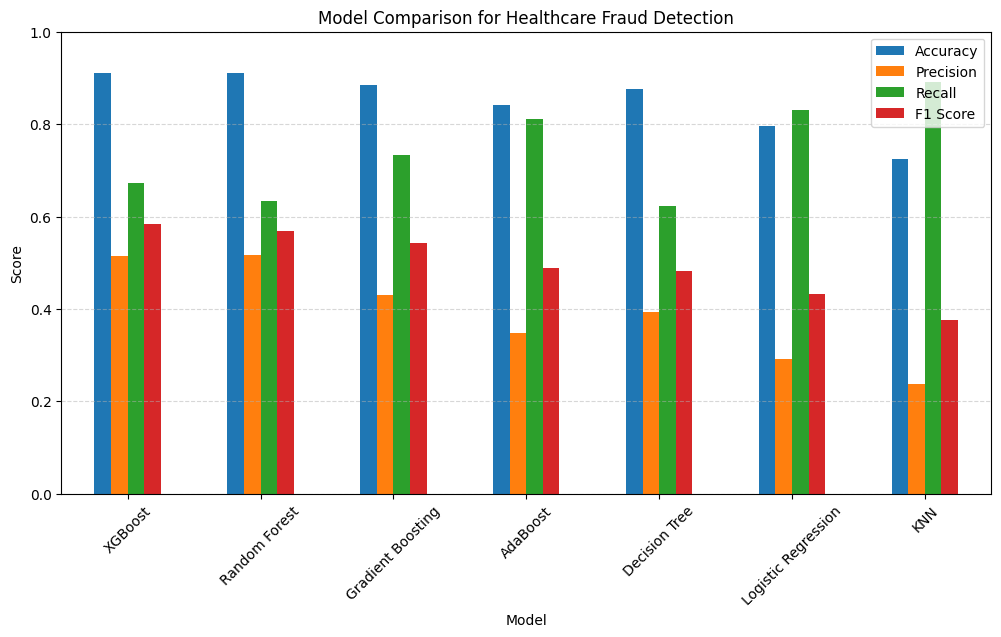

In [31]:
# Model Comparison Plot
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]

plt.figure(figsize=(12, 6))
plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Model Comparison for Healthcare Fraud Detection")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [32]:
# Best Model 
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)
results_df.iloc[0]

Best model: XGBoost


Model        XGBoost
Accuracy      0.9104
Precision     0.5152
Recall        0.6733
F1 Score      0.5837
Name: 0, dtype: object

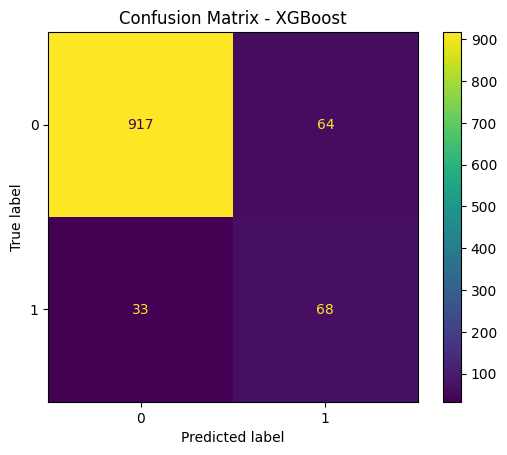

In [34]:
#Confusion matrix for the best model
from sklearn.metrics import ConfusionMatrixDisplay

best_pipeline = trained_models[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [33]:
# Saving best model and results 
os.makedirs("artifacts", exist_ok=True)

best_model = trained_models[best_model_name]
joblib.dump(best_model, "artifacts/best_fraud_model.joblib")

results_df.to_csv("artifacts/model_comparison_results.csv", index=False)

with open("artifacts/best_model_info.json", "w") as f:
    json.dump(
        {
            "best_model": best_model_name,
            "selection_priority": ["F1 Score", "Recall", "Precision", "Accuracy"]
        },
        f,
        indent=2
    )

print("Saved:")
print("- artifacts/best_fraud_model.joblib")
print("- artifacts/model_comparison_results.csv")
print("- artifacts/best_model_info.json")

Saved:
- artifacts/best_fraud_model.joblib
- artifacts/model_comparison_results.csv
- artifacts/best_model_info.json
